In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
original_dataset = pd.read_csv("googleplaystore.csv")
df = original_dataset.copy()



In [20]:
# Data Cleaning
# Drop the anomalous row if it exists (where Category is 1.9)
if df[df['Category'] == '1.9'].shape[0] > 0:
    df = df.drop(df[df['Category'] == '1.9'].index)

In [21]:
# Reviews to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Installs: remove '+' and ','
df['Installs'] = df['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Price: remove '$'
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [22]:
# Size: convert M and k to numeric
def convert_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', '')) * 1024 * 1024
        elif 'k' in size:
            return float(size.replace('k', '')) * 1024
        elif 'Varies with device' in size:
            return np.nan
    return pd.to_numeric(size, errors='coerce')

df['Size'] = df['Size'].apply(convert_size)


In [23]:
# Handle Missing Values
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Size'] = df['Size'].fillna(df['Size'].median())
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])
df['Current Ver'] = df['Current Ver'].fillna('Varies with device')
df['Android Ver'] = df['Android Ver'].fillna('Varies with device')

In [24]:
# Drop duplicates
df.drop_duplicates(inplace=True)

/var/folders/qh/qwbycz4d59792_lr1v_pflyw0000gn/T/ipykernel_88862/728844573.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0, 1], palette='viridis')


Cleaning and EDA completed. Plots saved.


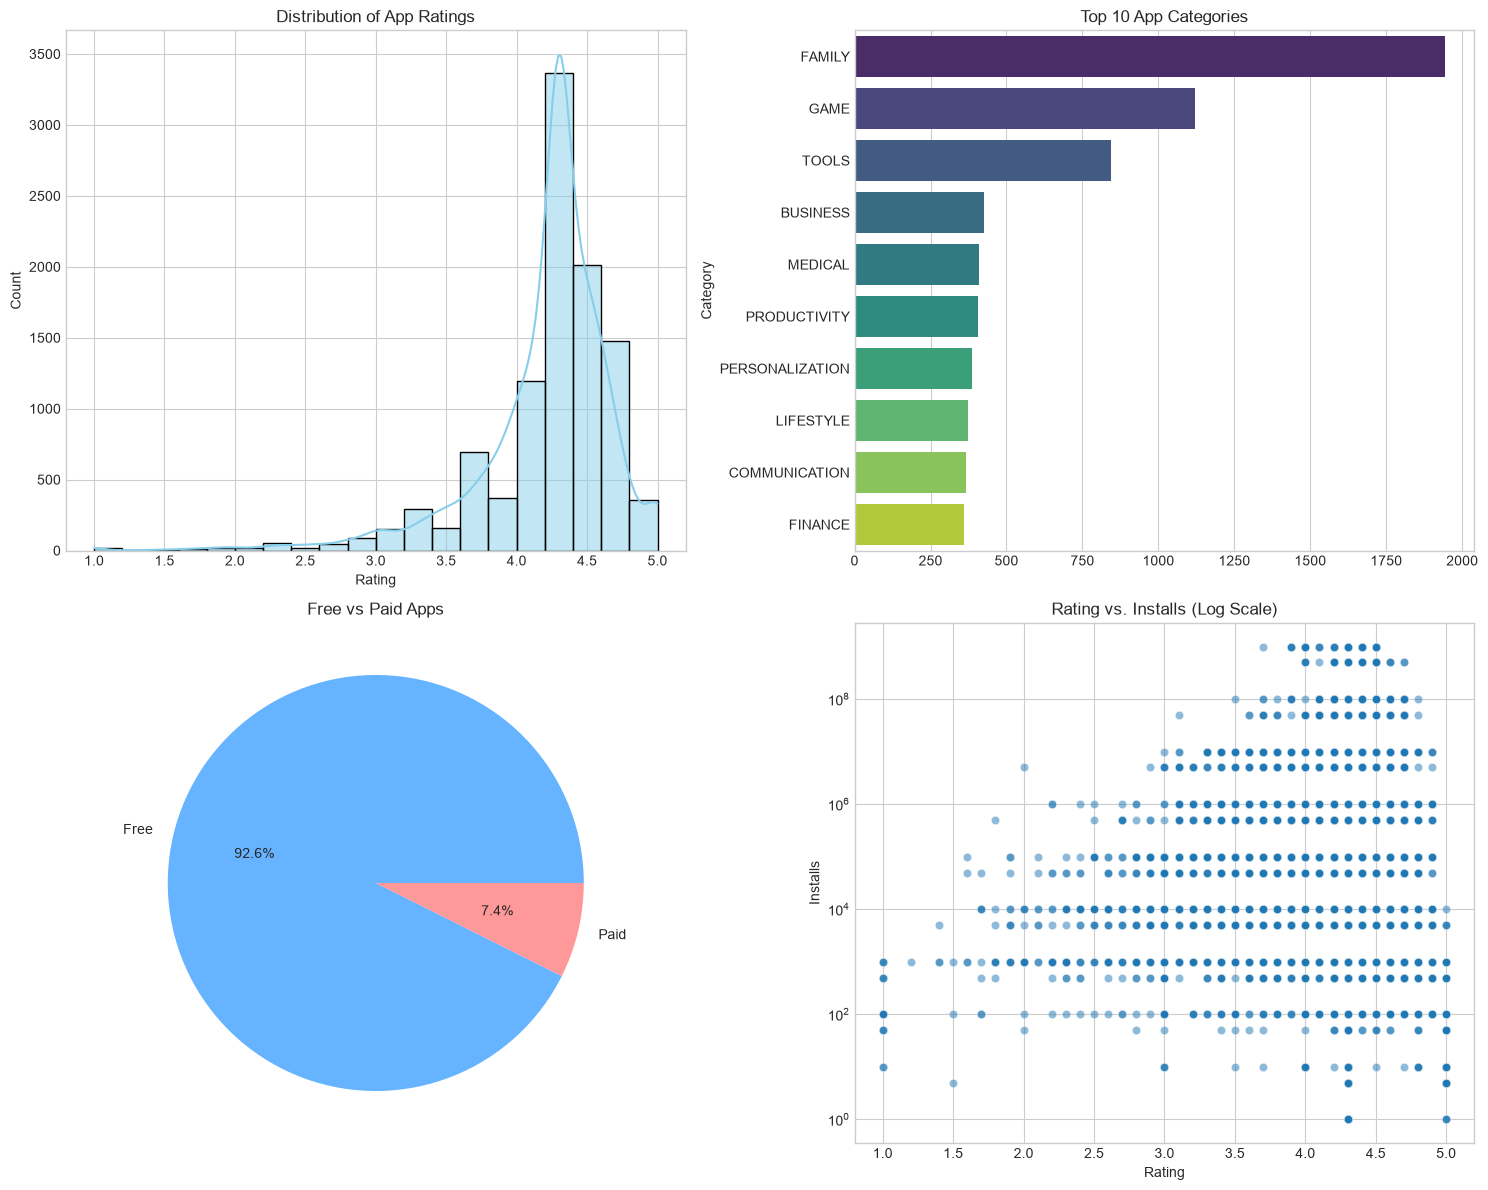

In [25]:
# 3. EDA Visualizations
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Distribution of Ratings
sns.histplot(df['Rating'], bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of App Ratings')


# Plot 2: Top 10 Categories by Count
top_categories = df['Category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Top 10 App Categories')


# Plot 3: Type (Free vs Paid)
type_counts = df['Type'].value_counts()
axes[1, 0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
axes[1, 0].set_title('Free vs Paid Apps')


# Plot 4: Rating vs. Installs (Log Scale for Installs)
sns.scatterplot(x='Rating', y='Installs', data=df, ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Rating vs. Installs (Log Scale)')

plt.tight_layout()
print("Cleaning and EDA completed. Plots saved.")

/var/folders/qh/qwbycz4d59792_lr1v_pflyw0000gn/T/ipykernel_88862/346741956.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Type', y='Rating', data=df, ax=axes[1, 0], palette='muted', inner='quartile')
/var/folders/qh/qwbycz4d59792_lr1v_pflyw0000gn/T/ipykernel_88862/346741956.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Rating', data=df[df['Category'].isin(top_cats)], ax=axes[2, 1], palette='pastel')


Plots generated successfully.


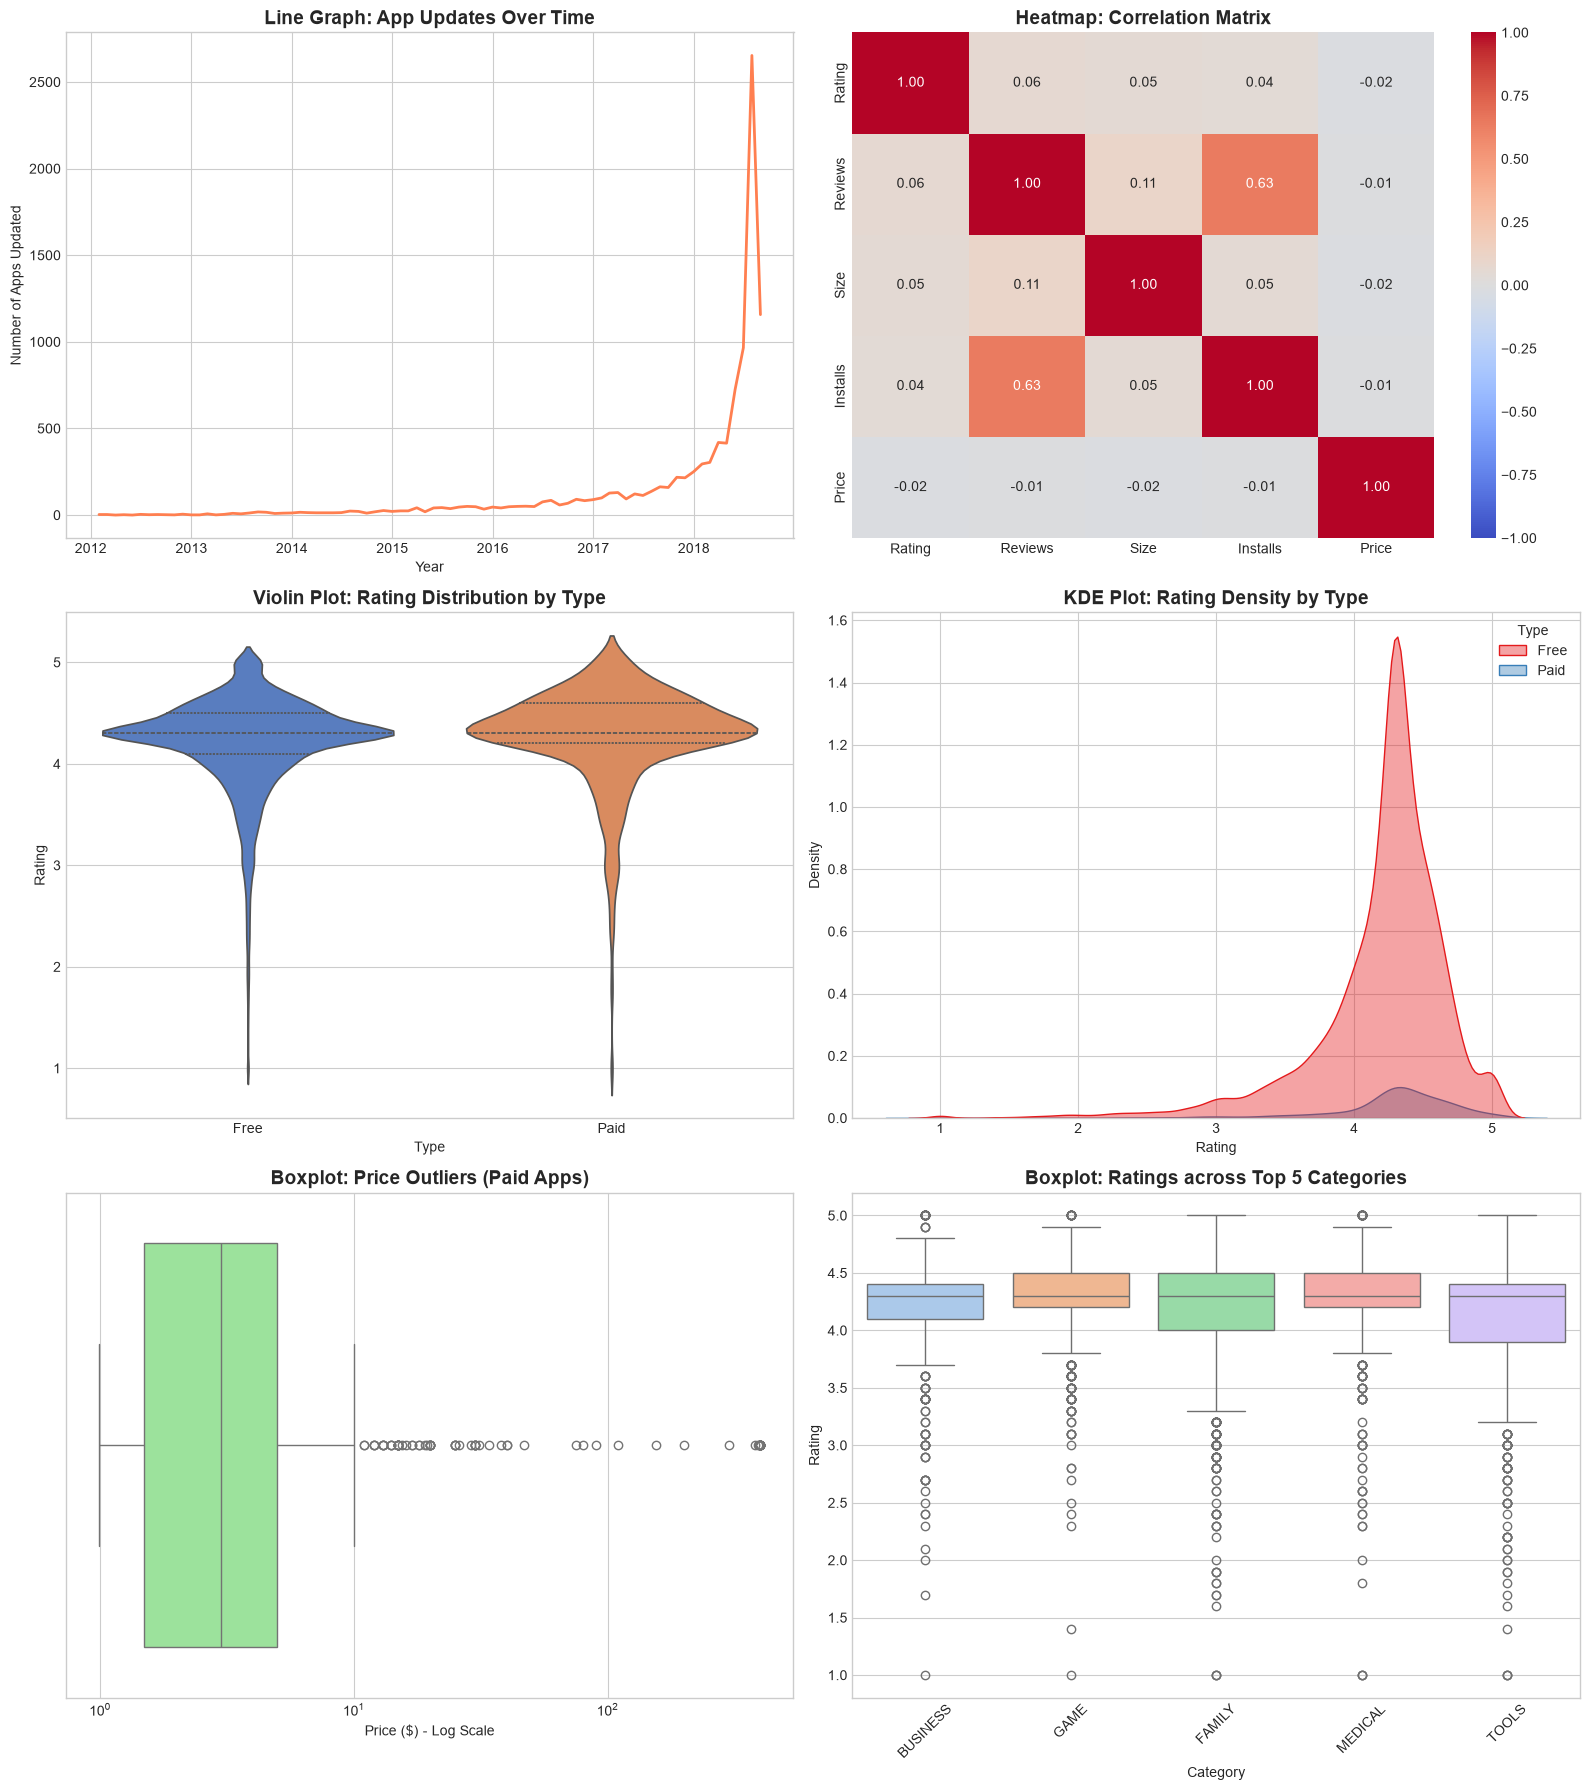

In [28]:
# Remove anomaly
df = df[df['Category'] != '1.9']

# # Convert columns to numeric
# df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
# df['Installs'] = pd.to_numeric(df['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False), errors='coerce')
# df['Price'] = pd.to_numeric(df['Price'].str.replace('$', '', regex=False), errors='coerce')

# # Convert Size
# def convert_size(size):
#     if isinstance(size, str):
#         if 'M' in size: return float(size.replace('M', '')) * 1024 * 1024
#         elif 'k' in size: return float(size.replace('k', '')) * 1024
#     return np.nan
# df['Size'] = df['Size'].apply(convert_size)

# # Fill Missing Values
# df['Rating'] = df['Rating'].fillna(df['Rating'].median())
# df['Type'] = df['Type'].fillna(df['Type'].mode()[0])

# Parse Dates for the line graph
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# 2. Setup Plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# --- Plot 1: Line Graph (Updates over time) ---
# Resample by month to see the trend of app updates
updates_per_month = df.set_index('Last Updated').resample('ME').size()
updates_per_month = updates_per_month[updates_per_month.index > '2012-01-01'] # Filter out sparse early years for clarity
axes[0, 0].plot(updates_per_month.index, updates_per_month.values, color='coral', linewidth=2)
axes[0, 0].set_title('Line Graph: App Updates Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Apps Updated')
axes[0, 0].set_xlabel('Year')

# --- Plot 2: Correlation Heatmap ---
numeric_cols = df[['Rating', 'Reviews', 'Size', 'Installs', 'Price']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', ax=axes[0, 1], fmt=".2f", vmin=-1, vmax=1)
axes[0, 1].set_title('Heatmap: Correlation Matrix', fontsize=14, fontweight='bold')

# --- Plot 3: Violin Plot ---
sns.violinplot(x='Type', y='Rating', data=df, ax=axes[1, 0], palette='muted', inner='quartile')
axes[1, 0].set_title('Violin Plot: Rating Distribution by Type', fontsize=14, fontweight='bold')

# --- Plot 4: KDE Plot ---
sns.kdeplot(data=df, x='Rating', hue='Type', fill=True, ax=axes[1, 1], palette='Set1', alpha=0.4)
axes[1, 1].set_title('KDE Plot: Rating Density by Type', fontsize=14, fontweight='bold')

# --- Plot 5: Boxplot (Outliers in Price) ---
# Filter for Paid apps only, and use log scale to visualize extreme outliers
sns.boxplot(x='Price', data=df[df['Type'] == 'Paid'], ax=axes[2, 0], color='lightgreen')
axes[2, 0].set_title('Boxplot: Price Outliers (Paid Apps)', fontsize=14, fontweight='bold')
axes[2, 0].set_xscale('log') 
axes[2, 0].set_xlabel('Price ($) - Log Scale')

# --- Plot 6: Boxplot (Rating by Top 5 Categories) ---
top_cats = df['Category'].value_counts().head(5).index
sns.boxplot(x='Category', y='Rating', data=df[df['Category'].isin(top_cats)], ax=axes[2, 1], palette='pastel')
axes[2, 1].set_title('Boxplot: Ratings across Top 5 Categories', fontsize=14, fontweight='bold')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('advanced_eda_plots.png')
print("Plots generated successfully.")

/var/folders/qh/qwbycz4d59792_lr1v_pflyw0000gn/T/ipykernel_88862/679770926.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Type', y='Rating', data=df, ax=axes[1, 0], palette='muted', inner='quartile')
/var/folders/qh/qwbycz4d59792_lr1v_pflyw0000gn/T/ipykernel_88862/679770926.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Rating', data=df[df['Category'].isin(top_cats)], ax=axes[2, 1], palette='pastel')


Plots generated successfully.


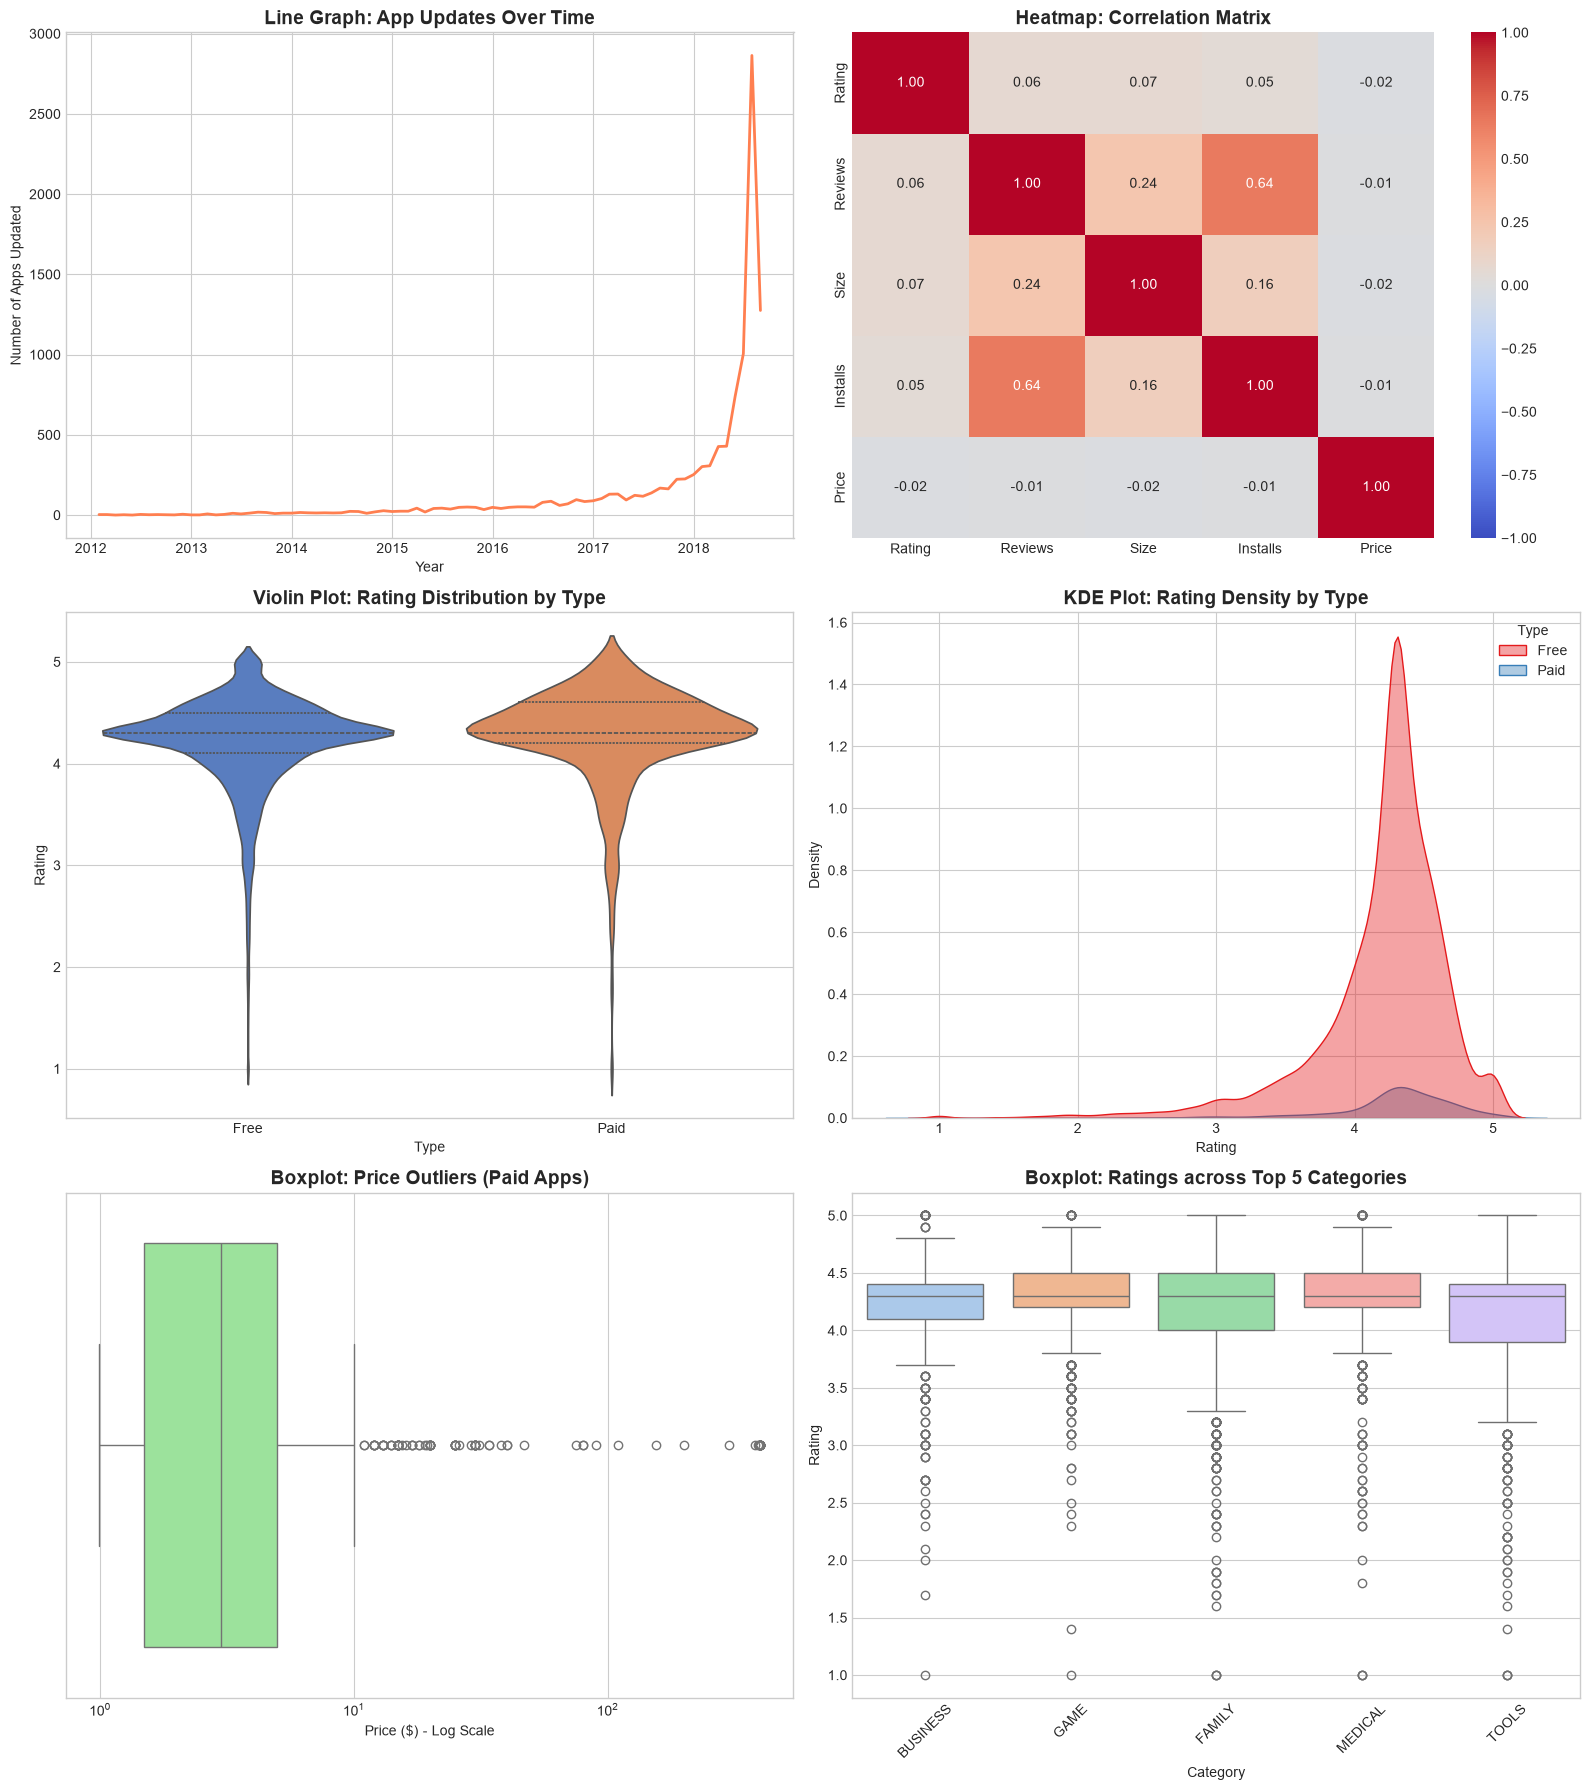

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data & Clean (Reproducing the necessary state)
df = pd.read_csv('googleplaystore.csv')



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Feature Engineering
# Let's extract numerical and categorical columns
X = df[['Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating']]
y = df['Rating']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define columns
numeric_features = ['Reviews', 'Size', 'Installs', 'Price']
categorical_features = ['Category', 'Type', 'Content Rating']

# Log transformation function for highly skewed data
def log_transform(x):
    return np.log1p(x)

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(log_transform, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Create and evaluate pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'R2': r2}

print(results)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
X.isnull().sum()

Category             0
Reviews              0
Size              1695
Installs             0
Type                 0
Price                0
Content Rating       0
dtype: int64

In [ ]:
df[df['Size'] == np.nan]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [ ]:
df.shape

(10840, 13)